Assignment 6
- Anas Khan
- 03/17/2026
- IS 362

For this assignment we're required to understand the distribution of the variables and the relationship between them. The dataset was loaded directly from my Github repository. Basic data cleaning was done, which includes handling missing values and converting variables to readable formats. Visualizations were made using seaborn and matplotlib to analyze patterns in the data. The dataset has 398 cars and contains variables like miles per gallon(MPG), cylinders, displacement, horsepower, weight and many more.

In [23]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as matplt
import seaborn as seabrn


# First we load the dataset


#Create a list of column names as the dataset does not include headers so we have to manually assign them
columns = ("mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin","car_name")

# I uploaded the data file to github as it was easier for me to access it, the url links to the auto-mpg.data file on my github repo
url = "https://raw.githubusercontent.com/Azekiel2003/assignment-8/refs/heads/main/auto-mpg.data"

# This line reads the data into the dataframe
# url tells pandas that the data is located online
# delim_whitespace tells pandas that data is separated by whitespace
#names assigns the column names I made earlier
# na_values converts ? values in the dataset to NaN
data_file = pd.read_csv (url, 
delim_whitespace = True,
names = columns,
na_values = "?")

data_file.head()

C:\Users\Anas\AppData\Local\Temp\ipykernel_11068\869504559.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_file = pd.read_csv (url,


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [22]:
# this line shows us the number of rows, total number of columns
# data types and missing values 
data_file.info()

# this line shows distribution of data like mpg, weight, etc
data_file.describe()

# this line counts missing value per column
data_file.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 28.1+ KB


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [21]:
# Convert horsepower to numeric values because the dataset has ? values and turned into NaN
# This line ensures that the horsepower column is fully numeric

data_file["horsepower"] = pd.to_numeric(data_file["horsepower"], errors="coerce")

# The dataset used numbers to define origin (1 to define USA, etc)
# I converted those numbers to readable labels
data_file["origin"] = data_file["origin"].replace({1:"USA", 2:"Asia", 3:"Europe"})

# Displays data
data_file.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA,ford torino


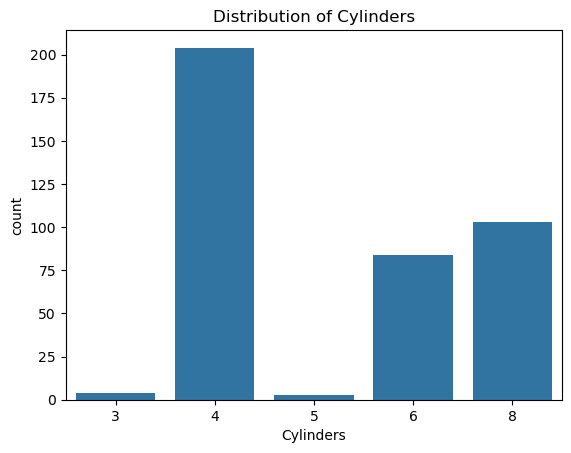

In [20]:
seabrn.countplot(data=data_file, x="cylinders") # Tells seaborn to make a countplot, X values are assigned cylinders and y values are automatically assigned as count
matplt.title("Distribution of Cylinders") # Title of chart
matplt.xlabel("Cylinders") #Labels X axis Cylinders
matplt.show() # Displays the chart

This barchart shows that most vehicles in the dataset have 4 cylinders, followed by 8 and 6. Very few cars have 3 or 5 cylinders, showing that 4 cylinder engines are the 
most common.

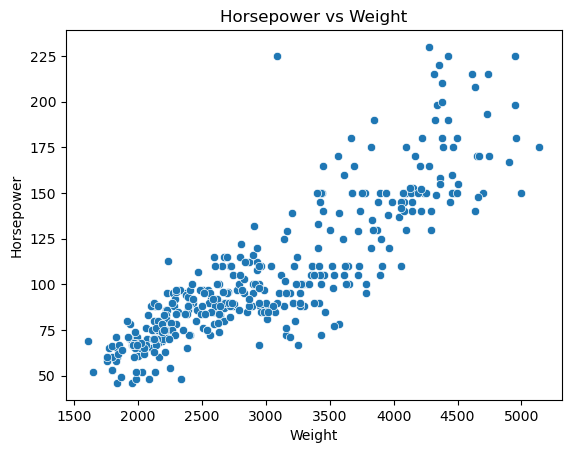

In [19]:
seabrn.scatterplot(data=data_file, x="weight", y="horsepower") #Tells seaborn to make a scatterplot, assigns weight values to x axis, and horsepower to y axis

# Adds titles and labels
matplt.title("Horsepower vs Weight")
matplt.xlabel("Weight") 
matplt.ylabel("Horsepower") 


matplt.show() #Displays plot

This scatterplot shows that the more a car's weight is, the more horsepower the horsepower increases. This tells us that heavier cars require more powerful engines, compared to lighter cars.

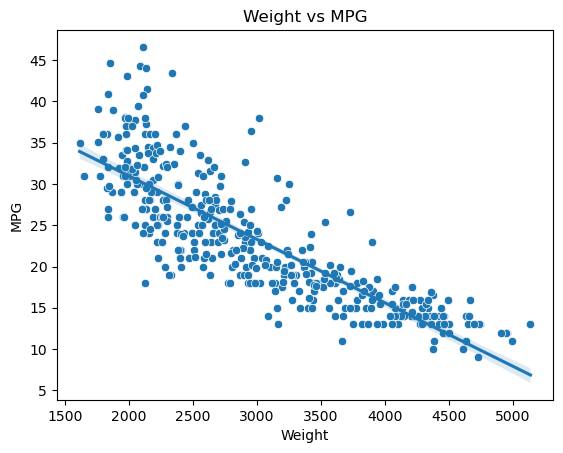

Correlation: -0.8317409332443346


In [18]:
seabrn.scatterplot(data = data_file, x="weight", y="mpg")
seabrn.regplot(data=data_file, x="weight", y="mpg", scatter = False)

#Adds titles and labels
matplt.title("Weight vs MPG") 
matplt.xlabel("Weight") 
matplt.ylabel("MPG")
#Displays graph
matplt.show()

print("Correlation:", data_file["weight"].corr(data_file["mpg"])) # calculates correlation between weight and mpg and prints it out

This graph explores the relationship between car ewight and efficiency. The scatterplot shows a negative relationship, meaning as weight increase, the MPG decreases. 
This shows that heavier cars are generally less fuel efficient. The correlation value is -0.83 which confirms the negative relationship between weight and MPG.

# Final Analysis
After analyzing the relationship between weight and mpg, I have concluded that there's a strong negative relationship between a car's weight and fuel efficeiny. As the weight of the car increaes, fuel efficiency drops. The correlation is about -0.83 and confimred this trend.